# Worksheet 3 - Scientific Visualisation MVE080/MMG640
## Geospatial data

Names of all group members:
- Daniel Esteban Lahti
- Ana Camila Jimenez Mendoza
- Edin Ahmemulic
- Filip Keerberg

This is the first worksheet in the course *Scientific Visualisation*. This Jupyter notebook has three functions:

1. It describes the tasks.
2. It (sometimes) provides coding templates that you can use as a basis for your own code.
3. It is a template also for the report that you upload in Canvas.

The tasks are of various types: some are to read some text and then comment on it (no coding), and some are about creating visualisations using plotnine. Once you have finished all the tasks, export this document as an HTML file and upload it in Canvas. 

The goal of these homeworks is to learn how to improve your skills in visualising your science. You solve the homeworks in groups, however annotate all the code (even the theoretical parts) with who solved each question. **Eventhough the homework is submitted as a group you will be *individually* evaluated**. Motivate your choice of graph, legend, colourmap etc below your graph in a separate cell. 

Notice that Jupyter notebooks use [Markdown](https://docs.github.com/en/github/writing-on-github/getting-started-with-writing-and-formatting-on-github/basic-writing-and-formatting-syntax#links) for writing text cells. Make sure you understand the basics. 

Throughout the assignment you shall use a Python workflow.
If you are completely new to Python, take a look at [this page](pythonbasics.org).
Python can do essentially all that MATLAB can, plus more. 
In this course we shall use Python in different contexts, starting with the [Jupyter Notebook interface](https://jupyter-notebook.readthedocs.io/en/stable/notebook.html). 

Matrices and arrays are handled through the NumPy module. [Learn here](https://docs.scipy.org/doc/numpy/user/numpy-for-matlab-users.html) how NumPy is different from MATLAB.

The below loads the packages required for this homework.

In [77]:
import numpy as np
import pandas as pd
import geopandas as gpd
from plotnine import *
# Currently in a plotine dependancy they have deprication warning, so 
# we mute warnings to have a better experience
import warnings
warnings.filterwarnings("ignore")

# A nice color palette for categorical data 
cbPalette = ["#E69F00", "#56B4E9", "#009E73", 
             "#F0E442", "#0072B2", "#D55E00", 
             "#CC79A7", "#999999"]

## Task 1
**Worked on by: Edin, Daniel and Filip**

Read Chapter 15 of [Fundamentals of Data Visualizations](https://clauswilke.com/dataviz/), then answer the questions below.

### Question 1.1

As the earth is not flat (and neither a [Möbius strip](https://en.wikipedia.org/wiki/M%C3%B6bius_strip)) when working with 2-dimensional maps we have to use a projection. Describe one scenario where it would not be suitable to use the Mercator's projection.

### Answer 1.1
When projecting a large portion of the surface area, as this makes the distortions much more significant. As these distortions come in the form of scale, such a projection is also not suitable when the scale of the details are of importance

### Question 1.2

A common form of visualisation for maps is the Choropleth map (e.g slide 15 lecture 5). Briefly discuss two important aspects to consider when creating a choropleth map. 

### Answer 1.2
- The color spectrum used, as lighter colors could be perceived as 'glowing', which could unintentionally suggest higher intensities.
- Whether to use continuous or discrete coloring. While continuous can be more visually appealing, it can also be more difficult to read specific values.  

### Question 1.3

Sometimes to avoid area problems, a more abstract map representation can be beneficial. Which abstract representation of Fig. 15.15 and Fig. 15.16 in the course book do you think work the best? Motivate!

### Answer 1.3
We find that the cartograph heatmap (Fig. 15.16) works the best in this situation. Fig 15.15 attempts to visualize a multitude of data all at once and, as the message seems to be to communicate differences in median income between states, distills the useful information. With so many factors (color, scale, location) it can be difficult for the viewer to retain everything in their head when comparing states. In comparison, the heatmap removes one of the most prominant visual features (scaling), making the visualisation significantly easier to read when comparing states.

### Question 1.4

When creating a visual, what are three sources that often cause unwilling misleading?

### Answer 1.4
Scale of the axes, unfitting data aggregation/sampling (especially if there is missing data), and non-uniform colors.

## Geospatial data  

For this part reading chapter 15 in [Fundamentals of Data Visualizations](https://clauswilke.com/dataviz/) can help. You need to have **geopandas** installed for this part (it should be installed if you have used the yml-file on the webpage).

### Question 2.1
**Worked on by: Filip and Camila**


Let us take a closer look at Starbucks. Produce two visuals where i) you use dots and ii) where you use colours (here you can represent countries without Starbucks as white) to show the number of Starbucks stores in different Asian countries. 

*Hint - you can merge left and right on iso_a3*

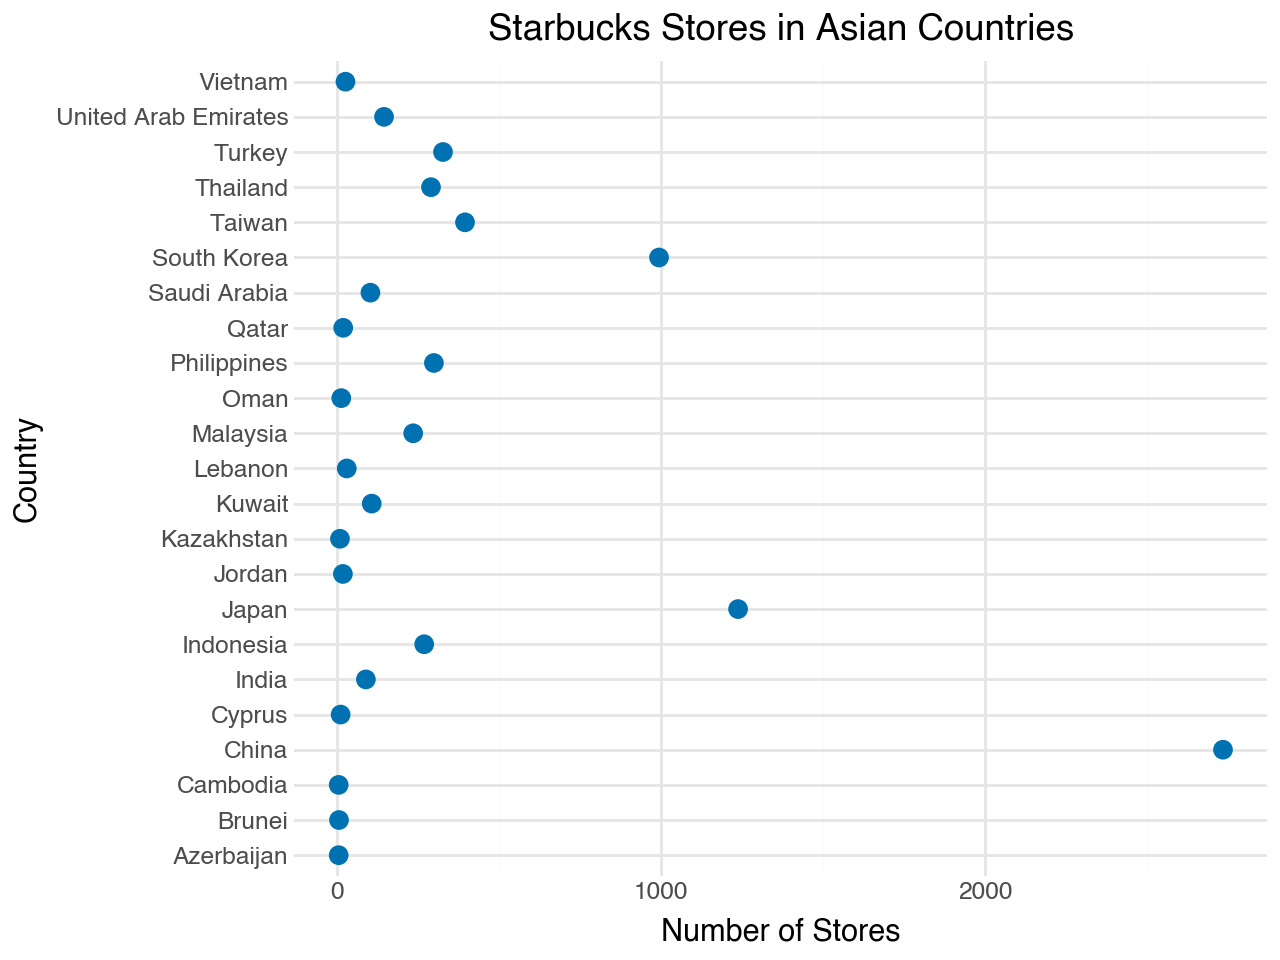

In [78]:
# Insert code here for visual 1
starbucks_data = pd.read_csv("Homework3_resources/q2.1. (starbucks)/Starbucks_data-1.csv")

url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
asia = world[world["CONTINENT"] == "Asia"][["ISO_A3", "ADMIN", "geometry"]]

starbucks_asia = starbucks_data.merge(
    asia,
    how="inner",
    left_on="iso_a3",
    right_on="ISO_A3"
)

asia_counts = starbucks_asia.groupby("ADMIN").size().reset_index(name="Count")

(
    ggplot(asia_counts, aes(x="ADMIN", y="Count"))
    + geom_point(size=3, color=cbPalette[4])
    + coord_flip()
    + theme_minimal()
    + labs(
        title="Starbucks Stores in Asian Countries",
        x="Country",
        y="Number of Stores"
    )
)
# Remember to print the visual

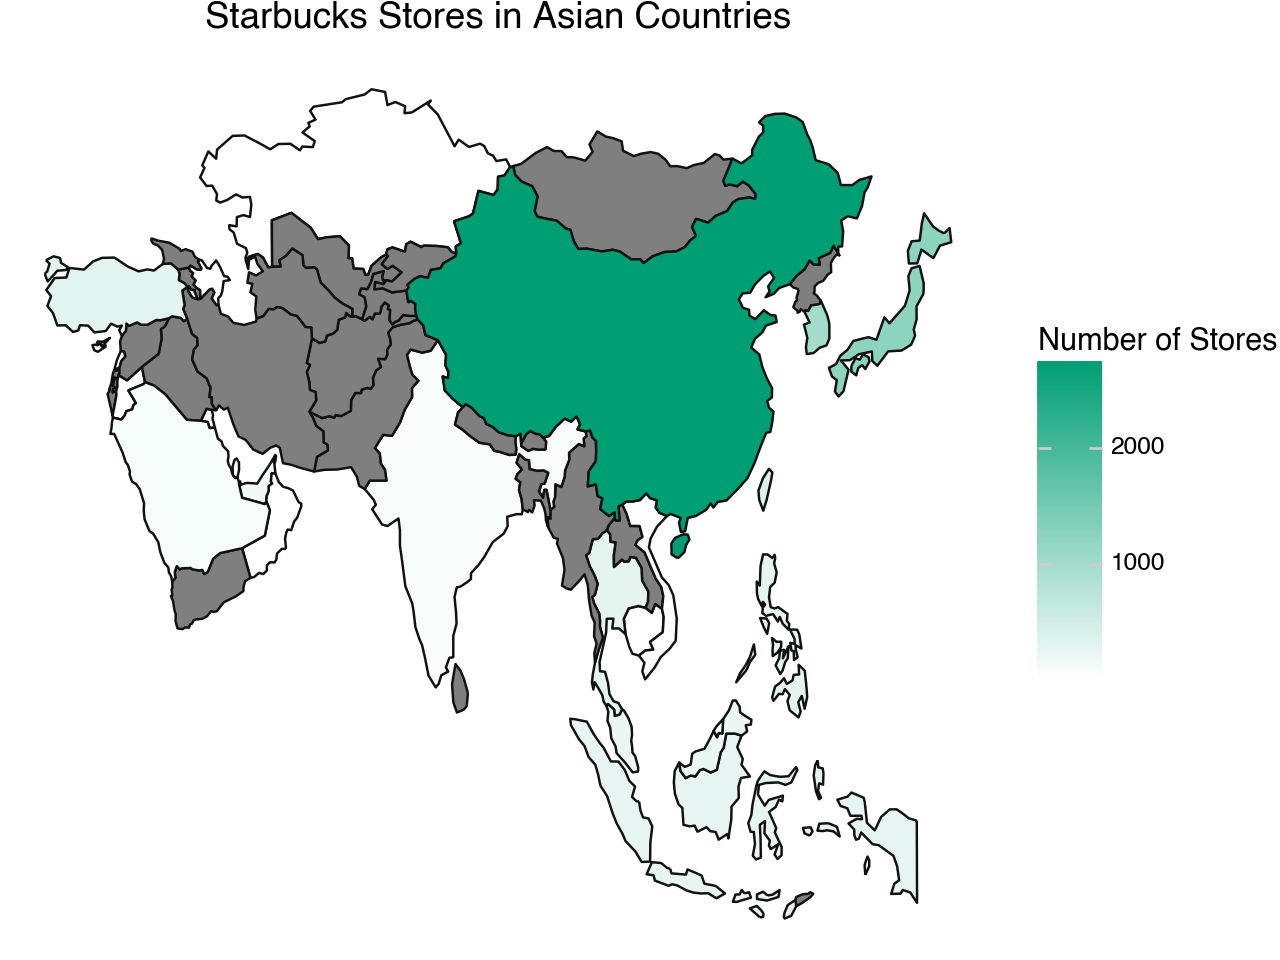

In [79]:
# Insert code here for visual 2
asia_map = asia.merge(asia_counts, how="left", left_on="ADMIN", right_on="ADMIN")

(
    ggplot(asia_map)
    + geom_map(aes(fill="Count"))
    + scale_fill_gradient(low="white", high=cbPalette[2])
    + theme_void()
    + labs(
        title="Starbucks Stores in Asian Countries",
        fill="Number of Stores"
    )
)
# Remember to print the visual 

_Motivation of answer_

## Question 2.2

**Worked on by: Filip and Camila**

On Canvas, I have uploaded two datasets with percentage of a countries surface that is covered by forests in 1990 and 2019. Create a visual which clearly shows how forest coverage has changed between 1970 and 2019.

Motivate choice of projection!

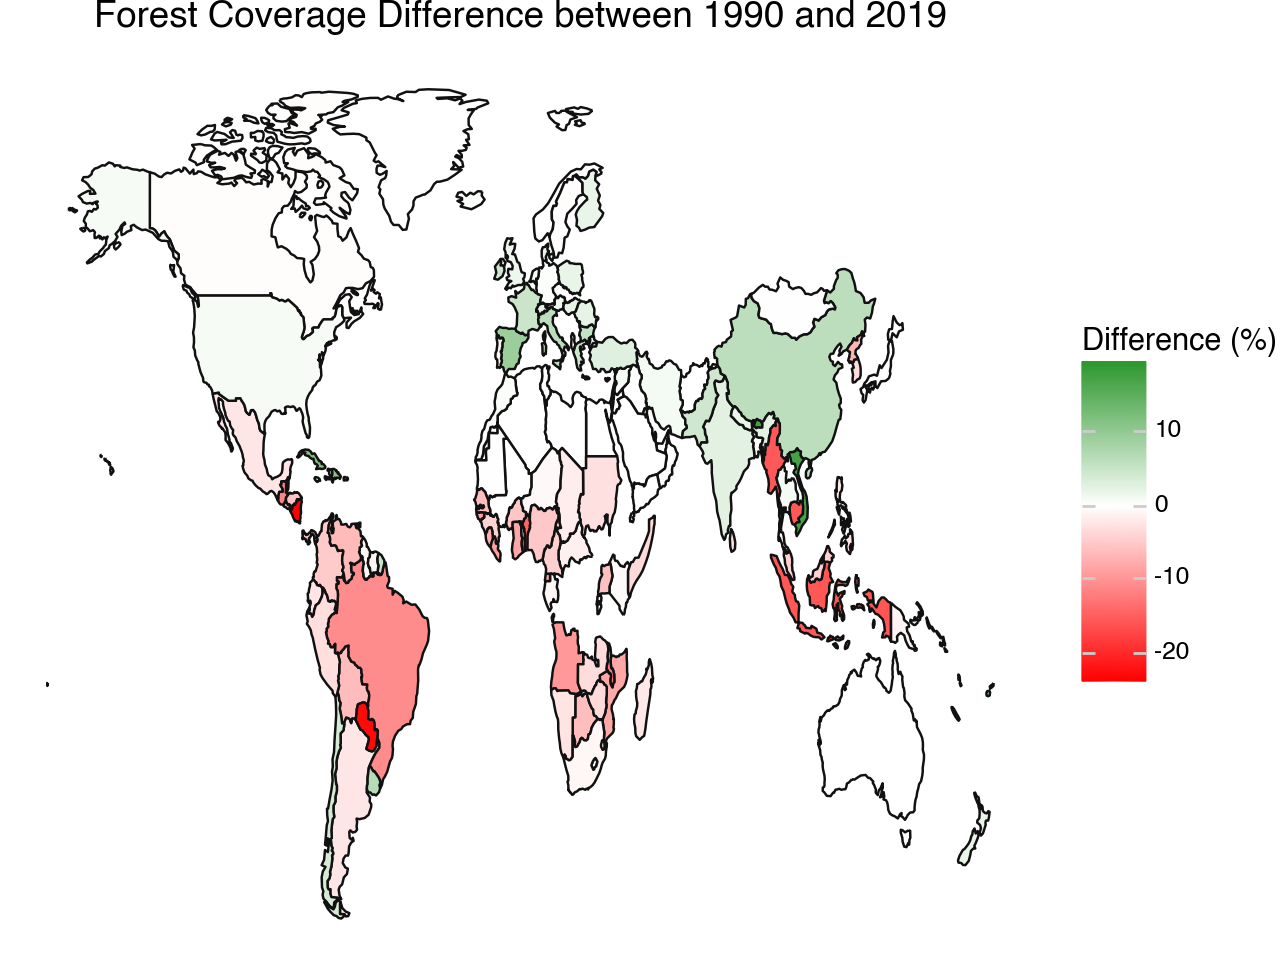

In [80]:
# Insert code here for the visual
forest_1990 = pd.read_csv("Homework3_resources/q2.2. (forest coverage)/Forest_1990-1.csv")
forest_2019 = pd.read_csv("Homework3_resources/q2.2. (forest coverage)/Forest_2019-1.csv")

forest_all = forest_1990.merge(forest_2019, how="inner", on="Country")
forest_all["Difference"] = forest_all["2019_forest"] - forest_all["1990_forest"]

forest_map = forest_all.merge(
    world[["ADMIN", "geometry"]],
    how="inner",
    left_on="Country",
    right_on="ADMIN"
)

(
    ggplot(forest_map)
    + geom_map(aes(fill="Difference"))
    + scale_fill_gradient2(low="red", mid="white", high="green", midpoint=0)
    + theme_void()
    + labs(
        title="Forest Coverage Difference between 1990 and 2019",
        fill="Difference (%)"
    )
)

# Remember to print the visual 

Here we choose a choropleth, as this effectively communicates not only where data points reference, but also give an immediate intuitive understanding of these data points. We chose to make the gradient white at 0% difference, as the lack of color, quickly suggests a lack of significant difference. We chose to represent increases in forest coverage as a green color, as this color has positive connotations in regards to the environment and nature, suggesting that green is positive forest coverage. Similarly, red has connotations with negative effects. The choice in color is clearly inspired by the fact that we want to represent an increase in coverage as something positive

## Question 2.3

**Worked on by: Edin and Daniel**

On Canvas, I have uploaded a dataset of ILI activity level, a measure used to monitor the flu activity in the USA. Visualise the activity level in the USA using a choropleth visual with discrete binning of the different categories. Produce two visuals with different binning schemes, motivate which one you think works best for this data.

The code below helps you read the USA map.

In [81]:
# Read USA map and filter away Alaska, Hawaii and non-mainland territories
map_USA = gpd.read_file("Homework3_resources/q2.3. (usa map)/cb_2018_us_state_500k.shp")
map_USA = map_USA.loc[map_USA["STUSPS"] != "VI"]
map_USA = map_USA.loc[map_USA["STUSPS"] != "MP"]
map_USA = map_USA.loc[map_USA["STUSPS"] != "GU"]
map_USA = map_USA.loc[map_USA["STUSPS"] != "HI"]
map_USA = map_USA.loc[map_USA["STUSPS"] != "AK"]
map_USA = map_USA.loc[map_USA["STUSPS"] != "PR"]
map_USA = map_USA.loc[map_USA["STUSPS"] != "AS"]

flu_data = pd.read_csv("Homework3_resources/q2.3. (flu data)/Flu_data.csv")

ili_levels_statewise = map_USA.merge(flu_data, left_on="NAME", right_on="statename", how="left")

#print(f"Map rows: {len(map_USA)}, Flu data rows: {len(flu_data)}, Merged rows: {len(ili_levels_statewise)}")
#print(f"Null activity_level values: {ili_levels_statewise['activity_level'].isna().sum()}")

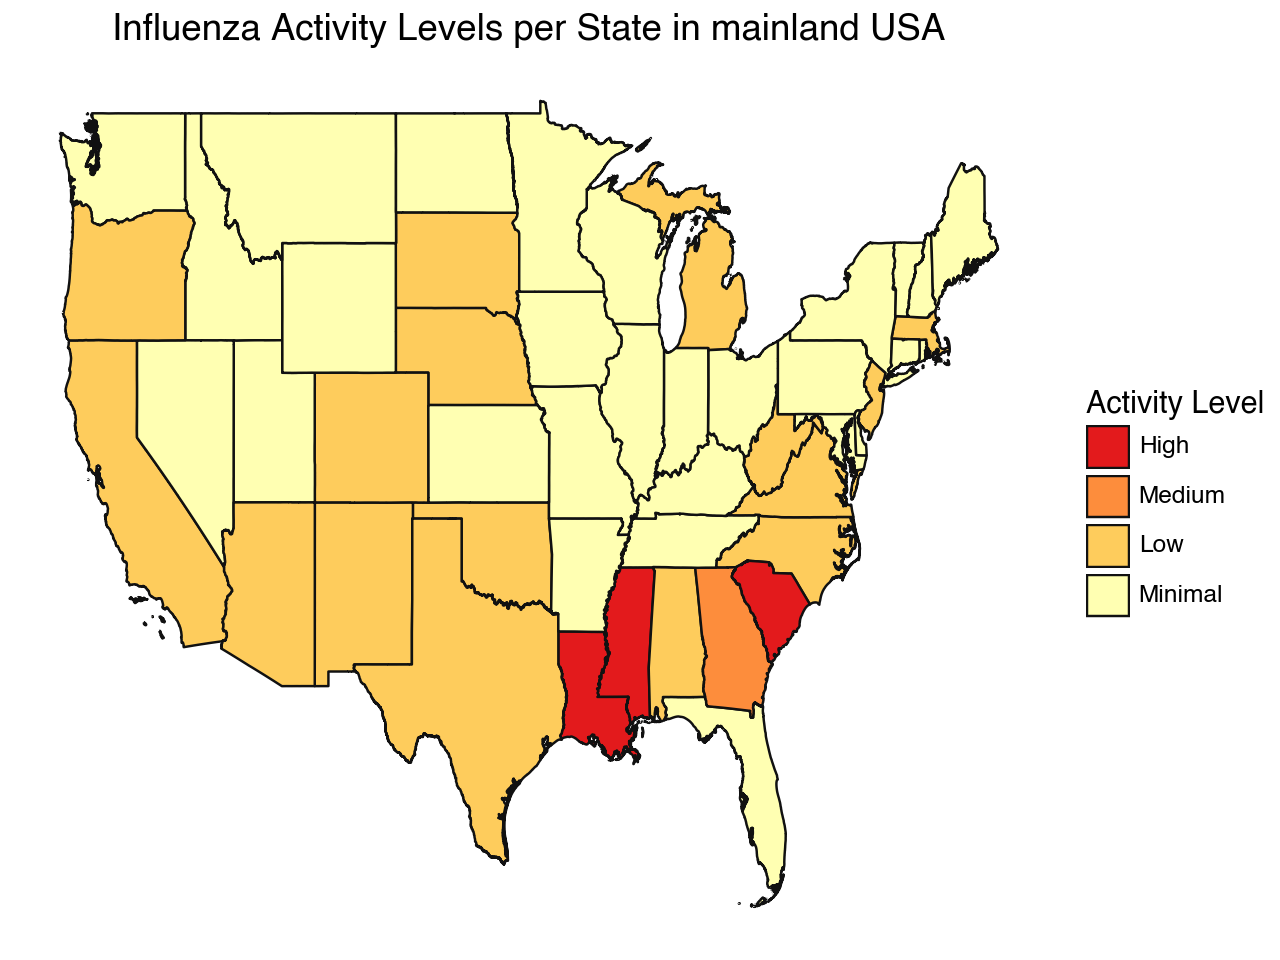

In [82]:
# Insert code here for visual 1
# Remember to print the visual 
conditions = [(ili_levels_statewise["activity_level"].ge(1) & ili_levels_statewise["activity_level"].lt(3)),
              (ili_levels_statewise["activity_level"].ge(3) & ili_levels_statewise["activity_level"].lt(6)), 
              (ili_levels_statewise["activity_level"].ge(6) & ili_levels_statewise["activity_level"].lt(9)), 
              (ili_levels_statewise["activity_level"].ge(9) & ili_levels_statewise["activity_level"].lt(11))]
choices = ["Minimal", "Low", "Medium", "High"]

ili_levels_statewise["activity_level_quant"] = pd.Categorical(np.select(conditions, choices, default="Minimal"), categories=choices[::-1])

col_use = ["#ffffb2", "#fecc5c", "#fd8d3c", "#e31a1c"]

p = (ggplot(ili_levels_statewise, aes(fill="activity_level_quant"))
    + geom_map()
    + labs(title = "Influenza Activity Levels per State in mainland USA")
    + scale_fill_manual(values=col_use[::-1], name = "Activity Level")
    + theme(panel_background=element_rect(fill = "white"), 
            axis_ticks=element_blank(), 
            axis_text=element_blank()))
p

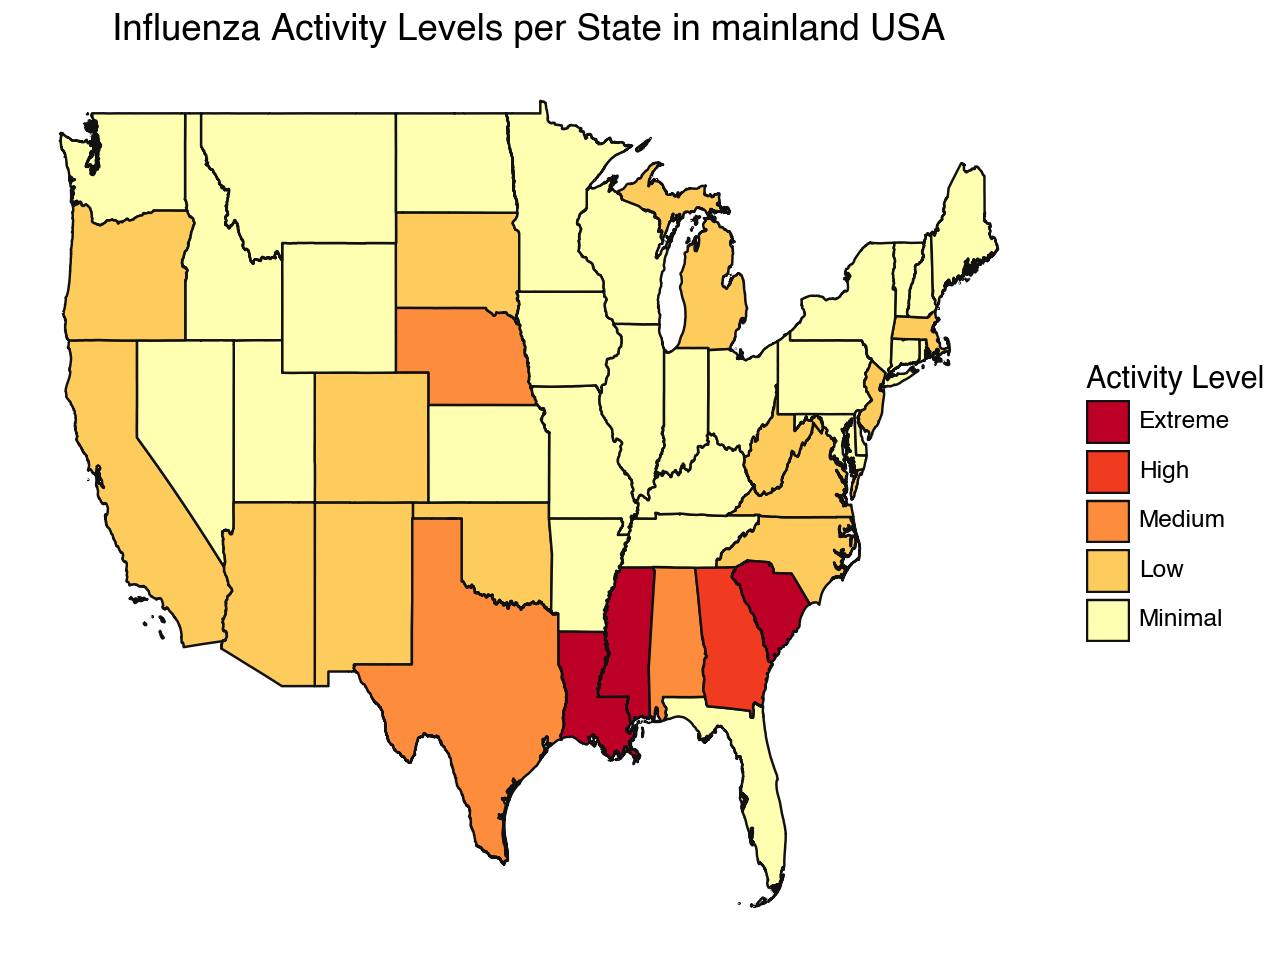

In [83]:
# Insert code here for visual 1
# Remember to print the visual 
conditions = [(ili_levels_statewise["activity_level"].ge(1) & ili_levels_statewise["activity_level"].le(2)),
              (ili_levels_statewise["activity_level"].ge(3) & ili_levels_statewise["activity_level"].le(4)), 
              (ili_levels_statewise["activity_level"].ge(5) & ili_levels_statewise["activity_level"].le(6)), 
              (ili_levels_statewise["activity_level"].ge(7) & ili_levels_statewise["activity_level"].le(8)),
              (ili_levels_statewise["activity_level"].ge(9) & ili_levels_statewise["activity_level"].le(10))]
choices = ["Minimal", "Low", "Medium", "High", "Extreme"]

ili_levels_statewise["activity_level_quant"] = pd.Categorical(np.select(conditions, choices, default="Minimal"), categories=choices[::-1])

col_use = ["#ffffb2", "#fecc5c", "#fd8d3c", "#f03b20", "#bd0026"]

p = (ggplot(ili_levels_statewise, aes(fill="activity_level_quant"))
    + geom_map()
    + labs(title = "Influenza Activity Levels per State in mainland USA")
    + scale_fill_manual(values=col_use[::-1], name = "Activity Level")
    + theme(panel_background=element_rect(fill = "white"), 
            axis_ticks=element_blank(), 
            axis_text=element_blank()))
p

Binning the activity levels into 5 bins accentuates details and creates more nuance in the south region, as opposed to 4 bins, which the data already came in. 4 bins show where the problem children lie, but not how extreme they are. We think that 5 bins works better to highlight a trend with the entire south.